# Before you begin: enable a GPU in Google Colab

This tutorial requires an NVIDIA GPU. Before running any code:

1. Open **Runtime > Change runtime type** in the Colab menu.
2. Under **Hardware accelerator**, select **T4 GPU** or another available NVIDIA GPU.
3. Select **Save** and wait for Colab to reconnect.
4. Run the setup cell below. It installs and selects CUDA Toolkit 13.0, then confirms that `nvcc` and `nsys` are available. You can also run `!nvidia-smi` to verify the assigned GPU.

> GPU types and availability depend on your Colab plan, quota, and current capacity.


# The Modern CUDA Developer’s Toolbox

In this blog post, you will better understand all the tools NVIDIA offers to debug, benchmark, and improve your code. With only small line changes each time, we are going to make the example code: safer, easier to maintain, and faster.

Across six incremental steps, we will: (1) understand how to easily find indexing bugs by adopting the modern CCCL API and Compute Sanitizer; (2) improve our Nsight Systems benchmarks with NVTX; (3) use CUB's optimized algorithms at the block and device level; (4) manage GPU memory through pooled containers; (5) speed up host-to-device transfers with pinned containers; and (6) parallelize GPU work by giving each thread its own stream and asynchronous transfers.

The code corresponding to each step can also be found in the [NVIDIA Accelerated Computing Hub](https://github.com/NVIDIA/accelerated-computing-hub/tree/main/resources/blogs/modern_cuda_cpp_blogpost/code_steps).

## An image processing pipeline example

In this example, we will try to improve an image processing pipeline. From an input stream of red, green, and blue images, start by transferring the data from the CPU to the GPU. Then convert those from RGB to grayscale.

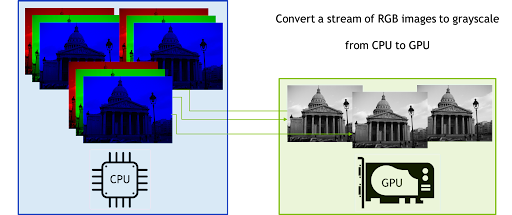

Then, for each 32 by 32 pixel tile in the image, compute the median by sorting the pixels and selecting the middle value. Finally, copy the median of each tile back to the CPU.

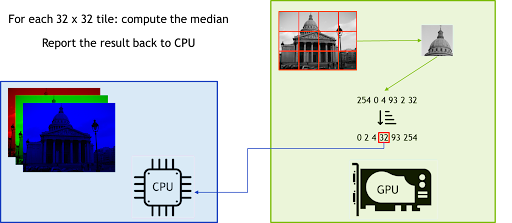

## How to use this notebook

Each step below is made of:
1. A **text section** explaining the tool introduced by that step.
2. An **editable `%%writefile` cell** where you write your own version of the code (start from your previous step and apply the new tool).
3. A **build & run cell** that configures CMake, builds the current target, and runs the executable.
4. Starting with Step 2, an **Nsight Systems cell** that profiles the executable.
5. For Steps 1–6, a **hidden "Solution" cell** (collapsed by default) that writes the reference implementation for that step. Expand and run it if you get stuck.

Step 0 provides the unchanged starting implementation. From Step 1 onward, the editable cell and the Solution cell write to the **same** file `Sources/<step>.cu`, so whichever you run last is what gets compiled.

> Requirements: an NVIDIA GPU, CMake 3.25+, the CUDA Toolkit (`nvcc`), and Nsight Systems (`nsys`) available on the `PATH`.


In [ ]:
# @title Prepare embedded CUDA and CMake files { display-mode: "form" }
# @markdown Run this cell once before starting the tutorial. On Colab it installs CUDA Toolkit 13.0, which can take a few minutes. Re-running it restores the reference sources and discards edits under `Sources/`.
import base64
import hashlib
import io
import os
from pathlib import Path
import shutil
import subprocess
import sys
import tarfile

cuda_home = Path("/usr/local/cuda-13.0")
cuda_nvcc = cuda_home / "bin/nvcc"
if "google.colab" in sys.modules and not cuda_nvcc.exists():
    print("Installing CUDA Toolkit 13.0 compiler and runtime headers...")
    keyring = Path("/tmp/cuda-keyring_1.1-1_all.deb")
    subprocess.run(["wget", "-q", "https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64/cuda-keyring_1.1-1_all.deb", "-O", str(keyring)], check=True)
    subprocess.run(["sudo", "dpkg", "-i", str(keyring)], check=True, stdout=subprocess.DEVNULL)
    subprocess.run(["sudo", "apt-get", "update", "-qq"], check=True)
    subprocess.run(["sudo", "apt-get", "install", "-y", "-qq", "cuda-compiler-13-0", "cuda-cudart-dev-13-0"], check=True)

if not cuda_nvcc.exists():
    system_nvcc = shutil.which("nvcc")
    if system_nvcc is None:
        raise RuntimeError("nvcc was not found; run this notebook on Colab with a GPU runtime or install CUDA locally")
    cuda_nvcc = Path(system_nvcc).resolve()
    cuda_home = cuda_nvcc.parent.parent

os.environ["CUDA_HOME"] = str(cuda_home)
os.environ["CUDACXX"] = str(cuda_nvcc)
os.environ["PATH"] = f"{cuda_nvcc.parent}:{os.environ['PATH']}"
cmake_cache = Path("build/CMakeCache.txt")
if cmake_cache.exists() and str(cuda_nvcc) not in cmake_cache.read_text(errors="ignore"):
    print("Removing the build cache created with a different CUDA compiler...")
    shutil.rmtree("build")

bundle = base64.b64decode("H4sIAAAAAAAAA+1de3PiuLI/f/MptNmtvWaWECCv3byqCGEy1OZ1gcxm79wpl7EFeMfYHNsk5EzlfvbbLfkh27ySgSSTkWpqArLUarVarW71D6ida1/omen5XtEf+/9aSSlB2d3eZn+hpP9ub5V2wte8vlzaguaktBp2kmXk+ZpLyHMM9RqLPoD1VwembQ5GA9Wl/x6ZLjWUj/Vmq3F5QTaLle18bug6/1DdVwaOQV1bNQdaj6pQqVPPM+0eOatenF5XT+stUru5IbXrk2o+l/uZtPumR+hYGwwtSkYe9Yjfp6SGGkeuNP0LUCHnmg1/XKLUrs7zxHeIZ0Jzs3tPutTX+0i9Vqudka7rDMip6X8YdYDye8clA8elxLS7jjvQfNOxC8SjlPR9f+jtbWz0TL8/6hR1Z7ChDwfrbJobMEaRvcqZtm6NDKqk6mO270zLItrId5C4rlnWPdEtx6YZbohmGwT7ssnR8dBxfWoQnVdpbo/6HtFuNdPSOhbNwVBVwwhmr+QIuaie1xlReH3aaH+4Plab9avLVqN92fybrNm3pmFqG7quW2u8hdqunpK1283idrFUNOjtWg64zpANCF98bN+wd1nSFx8bJ43qhtiCkQbKm8XSur6uD4fRg9aH6tnZ5V+k3byuMyG1qM9XExabwBayDc01ch71ldp59c+6ivVqq129OKk2T0illOfPbm4mVPIO8Oj9WfW0RdZ++ZqqeiDrXd2xdTr0vbV8epRqs/ah0a7X2tdN0MA1GxbslmabpYlHdUB9nY59ahvUWLe0QcfQ1tgcGwNcTHI5pPb5Va5r2oY6DCTM60iz/t/XjWb9hDU/odCEEtCVQBWoPvJx0T0CSkqopvdBUnRInC5r4IN2uaZm5XKaYahxc6WkdjSPqtR1HVcN98+kyqI+yue4jqmg6UPToqozxM3gTSZy1Wx8rLbr5JeDXw5ql+dXjbO6Gm7ePZTI0d76TUDJPfzlK5+msBBH0XiWaX+B/zqu5pp02nDXx2eNWiDAvb2YWsQIKv7eHv6fz4ihrHpDzSb8z6ypBg1XN7lwgG+aToURUe1bf0yE17MmJnZZ3ewSozxiigR7bKKZyE52M6ap6mAkU+9nTTrddXUTz4y0pMlvJenCDG1fA9PgkqlPZglkOrnViWbGmEsS0va0EdShadtwgs5rMEtkc4mvTnLzh16SAHfmDKR6vku1AVmw3SxxLjrU6qS6MAdPE+5Le+EvV1IO8ErGmBP/lXdL5Uz8Vy7J+O85CnjyVyc362emTm2PrjcMavtm16TuHjlvtHM/54IG72HL1pzhvWv2+n4b3OU9Er0lip4Hb778x3qlVNkkZ5rrkXNqQfQGbi+GR7hbXbOD/q6X43751bl6cvnXxdll9UQNg81ScatSLOejBh+qrQ9q6/qcrHU3tR1D13e00pZO/6C73e2yVq7sbpZ2u9pWd+ePP7qdSkcz6Ob2rvY77Wzp252tbaO7u0PLBvTaRn/e7DKircvrZg3c/2rtA0QyhGS4ObusVdvIDoYKqQ4PGEziblH5s/QUHvguguGo5VEY8aT+vnFRPyH1i49ZYvOGn9jpURwo82fIgqHjxkW1+bd60mgC/dAizB/BNmCKLPapj4e40C61WPRFhprfL/JIGv+xQEqzfWLy0GfoOhDXwmGI7UhgzCFMJr5pGZQo/5fP4SHQBaWztQFlBxIE3/a0iaQ4DesfSPW4dXl23caYFYkpYRMW2C54WbABs6IQ3HgbhnNnW45mbNxOEY1ww8AGmMpX/eYKAtb6CdNxAtF1ZXvnkLcOtf4B4/rwnmIaoXzuG/f/lLByKbYlGmOm/S9v7Wyn7X9lsyLv/56l/BxoGDnQR4amuiMw/wNa7B/l4iew+bBCqDEd7m+JrW6pDvZdrNGsnuPC1hok+uI4aGR8RtLglybsNgbMW+1Ptd5sXjYVvHLLE8MhX8n/sr2E3epMS30C2koOCTbZD56CXVGw9qdD1rA10vFuMh/1xuL5xt6ejq0ODsgau7hiak9Mm6xhnaq+R49VZc+J5hMLWQsenYEdDx7tQV1MNi7wDAc/pT5jtAVnnt1DtvL4iA0PJjPiOeKJjk1fqd802ur7auPsulnPh00e4O8DueuD6SJKCezBxgapWqbGb5Q0m7CrWDI0x9TKjdhdLHsNMjokI9P2f1f9fdbrT+ra1EJTe0tdHxuiHXapUSA9l1KbndMda0Q5SbDZtu+AQUaaMHjP1e75k5yq9iyno1kgjFvHxMN9MBz5tHl63HZOoZkCY3h+yMc7YgT3xW6BTHnSm/qkU5jQGsYoIHvkzjT8Pn/Zp+iIwHozscF8a5wrftHWB101CGcbmht0jGuOj3quaXD1YgwgqTGIjvdoGOPimPwGYnH0L/zNO/7mxBwUx/upjveJjvdix3ux4z2sSMDlsTPCi9N7ovep/gVOags2ES6OY1v3ATG8i/b7Ab98vTtBt0j1x+SAS4P8+ivwcZCSx3SZJITB1zfsEE/MhImhHHAWbJT9JFWmUvxO3O118BIf18iD/UmZWnk+XtVzffNGFhINF2NAB04wDyziGn8yP8O4YJ19U1d1zfMPAlU4UkrFCrh8RNAtbPwbOJDbv++K9b2wvlzeEus7UJ/ns3jIPSQ3CMoo3B8Dapiwy5wuv731cR9GmhNOkYvNp3B0aj4aRxBZGw3JX42T9geunx8arfal2mr8T/1o2gY6Z2Mp4f59l9R3oZozJbdAcgv8NHUT5CP1cqk/cu147KoFDGmBiLy+BuYw0EgUDphdWPM7ynNBsRKjFjAKqsr7wEKGy4PPPsWLD3OO33yOB158Jwq7kDXI7MSQ5Bn4pRF7/+UJ+nmroVln2zOx67iJT0ybEWNzYKPhBkxuSVYbD9q6t/W+69jmfyhue5bz8kZumATha9fXICBAt5kyBk2XGJqvhRIECkFDJS8QxsRLOBuiuXj88PMtOpJ4L6DZGXU68N6DLpE2iNp7eEhKqBKiYmKdaB3xOFVCW1fahz8HZMoy7pPffjPzieM/6v0P9DZhfcr78HImhX/yGQeC8c1k/5kc8VX453O2GdMKcDP29pjz4N1pw7BbIeoVSDKQZp0ZL65nbA9ybfYEG1eAScCOChVwYBoGs3Woc1rXpy6TL0i+ENmNUJeYiWRLNOHs4I8bge4qUySSJxuksi8cA7zbJ8HspEwJWi1mglBH2ayFkT4Lpp0xAdGlIljGTKaOp6sY1xClevHOo+Ohy9LA4loeks3K/qQ2sZWHNhDRTWx0cawyWjesTWlmm7+hTdR+YsvGefW0rp7VL04ZYwn5LtIzYDZB5l3i7TQGWZsWCmMy+QvwZz9Wz66R/NYUm1u7ug6NEZqiyMQGPiiuqxeokMdcCdxpSce1wL1WfJg6kvkysk3CY5MD8XXoTByRPrdwnuoq0bQKZFJbJZZZgWzlAw/iESP0Vj5CZ/VzQB//MYOUHjNIsNhzB4h3Uaznf+eFE6Q5Et0FAawyNIeUBXZRUp41YXZtqLlgFCCWQiI/D12tN9AInNXRA+yUm3ZgRDwLR0R8xGQcOwiI3gkh0Dsh6Ek5f5HTlzTria10Gm+laGJRliTqlY2z4SQ515CQ8qvAmGAc3sGB+x/qdEPPNB8u58L0ekum11k2f0zISyIZHqdTNHQy7WQ8NbwPDma2mmHwEadgmSuHphNsJiz7HM7oQB/eK8LaxvYOXIYi+mJKfvb0CySm9MHx/LZzQm9Nnc4XS3LwnjB477kH7wiDd5YxuLhoZ9oIPGFwTnEbfuGhJKxOcN3ClrN5ehyda0KEHDs95mCT+zgt4EERI0jBUdpPtkc3iDXnHqFOTUs1zFtFPMALMdXiOJjRAk3vRQGnL3kODg7CoYU+R0dHoqIJyy4swqRdF44uvpu3vKfUP9M8ftWmTFmP0DCKKxJHXkJ0D6t0nwjv03chQoh+IC6NENjPlwmfcmwjVjT5yILwM4FNMjAmHQ2cfxBD4HwttIGiQ1ncNE8wdOJe4ruo7eCeSrP/Hty61JE2m0/sEOvdXLuQaN57XPPOI6nDgi/ag8szH11LRXcF7F5EuD1L+i0pb4R5O9wjYS/TXglWpj0Tdn3CvCw4xVRYMWHFsf3not6hPQyhCiT7iNoGPvgUO/yfo0ssM/81uHRBP+lQCAr2yYNwMRPzgoVf1Dsjn922f2TXF17fGVkQvQb38UJ0kbhaz4blLBihZC/DeTayToxLeRZgbX86a1OGDSa8Xo6rH8Q1TU4PnDjScxxjLUUxJ5CCIPFhRfmfCF25IvpY5uT/drd3Ssn8X2l3a3NT5v+eo7xQ/g8UfWNgoOodTUkNZjqkx2PVFjvnM9XCyBMGnjhsyI1MST5XSlLoRSrozlLbQ7gh4UshZFT8+yHDgZD2UUCSoQErBjkUr0J5v4N2QawEut5B5eho2WnQCdzVHLtr9kYu+zjK1DxPnChNtEee4F0hnNpBIiV6JKZR57SYT6MTt8j2RpflSUmk4IIe3+rizIQ8BjuMP40LBNxg9XO0er3hSOXEi4xqEM0g0UJAK7/8jBGmiMRZF9mHQHxQaswWjKc8LeczWdXV5D8VkNE4v3gKNGg/KQsqPEonQvmjF8qFFsgj906QI33SxuHB1wS9DxzvH0Lnf3q61q8ijcq2x61J74gJgkIAYOUkNP9IfEKGlVfMyLEGTP0FKwLqyohn+WJj2aA8zp2NYkwOC90bNjFoZ9Qj+JlHIGB6eIfsg9ShZw/Rij5BFx62AxMy1LLzPXIM4PjhrPMRVU6ezRr0T+EPC2TqNc/cVLGw2InUHp5XhgGWxpuQ2xVUkrVWTWM8TyVZwwk6udyMMwolYql4X4j5KzIrmDWNrzwNjTrIvKQgcQoq7oHp9EzqsmQXFbcBqmP5RMiizlOh8iQVSuZU96NdL4gyyoYLsn7V2XCcqZkPEuL45p/84jlx3rkg9v2+M+PC/sWTQs1uYlYz60iJfQ3OgZIkhFsvVcP2XyhCgW3Ra5Bpdplml2n2Hy/NXh+Dp2/i5xo1sEsEvX4XIxZMqI/s+IMfqFG2cxedbS12nwP+HP+4Pud84vU4b1mD/3yq/Mqbh1MNbT777F/w5zBRu7eHbojKu6l90F+LKgGRfSSRk4gBiRiQiAGJGHhmxAA3aGzZguw0v8tO3iOwKC+4AQoc1PiiNCLHPAHeLzJ/7Ht9eJ2S8JcFN1Fll6OTQ9AjmOiEfsw1xG4K4g9mww4EL3YO6kBomdHuJUAr+Nhcvgo/FwrRtVEG2mBQ3cJ7KSVwmY+Scph8zfQ1YwonpfUfHkWqtzxSnSeQyvIzB7HxsGIQxgKrOBOhUSDftrRz5z9XjqGpj6x7/PImLT2J4li8uURxSBTHxHFfG4rjWz+uvfSS/Caq1YwxG/9RKZcrW+nv/9guVST+4znKq8V/CNXse3o22P/F/nA4idpzgUMkOkSiQyQ65EfIlEt0iESHSHSIRIdIdIhEh0h0iESHSHSIRIdIdIhEh0h0yI+CDuGzwGunpmb36NXI61eVtQbfFUHIsfaav3ECeMJf9yAusg/7GF0bnjQCWuuW4wyJpztD5hXBmrAnd33HmjAF/N2KiC67iQMRYl9D5dS7I1tlFYGEMgLCsnxACy5KEGKBLJ3hkHlftjhvJnSWWtR0FhHGsx0kpiSu8jm3h4GdhF5reYmkeeNImlgHnKEy+UFCOViCtpHRDInG+d7QOAsvfHDzhXCT4BqPMFcnowIS2yOxPW8Y2/PYDcPtcnqXSHjQk+FBTzqqLkf+1LPqO8QYLSwDROakJ/7Do5MeI0b+AOse0jGR0EeCnCTIaaVfVSPLCkr2h/mWP8ac7//Z2c78/kd5c2tL4r+eo3z/+K/OBtfb/uRRJo7xZMCYxH/9EPgviWyRyJb5yJYTCBc1l6e9tATKBQyhFlw9166PyTFeyDQ1wxy3wvw/l1/yAZNRZ28vWRsuWRINUi7wthcjy2qDMhXIFmiVO6JB/fHZJZimVq16of5VbV6xVy2u+i2GDIDo6liz2VeUvndG7vG9TxNXRPtpiE2kskn29vbaoPWtYMa4A9Rg+t+CBWE9ox/VYMusfqH33qdygOER60rp36lII0CuqIs/Ey8o9jq7I1u36C3sdxfnEkMzkvNTxCnli7wqHlyEgzDlFHcPhwZofgYaEEFA4FihDPrBBcHRUKZXSGMHRMDBHBzBMkA84bZJQUOExPYGGOUsTiTZQASNvCA0IaEpEpQgQQkSlCBBCRKUIEEJvEhQggQlSFCCBCW8dVDCtUdZMPro/DpEk0ESDmyXh4EUxHzhS0W8YUFYgj8Ch3ner4Ck4AezSmJPLtxL8DIW7vPpM4S7fVgPCHZV1WBThpdRhsiNf4WzF7/s5FMpoXklSJTM/tyWK35Sqyd+NquT3194uIfFJ89dj2KP+so3qeHkVL8ExDwOECMxERITITEREhMhMRFvBRPx6r74JShbyfy/GgUES0QCzPv9n1I59fs/5c3N3R2Z/3+O8qbz/51Rt0vd7Le58A/Mgj12Rq5OF0UH8G7L/JYZiSaQaAKJJpBoAokmkGgCiSaQaAKJJpBoAokmkGiCZ0YTIEwgiIVwe/A26RyyFmWdxW+xCrIkQUQ1dBwLwqouCarDCCtiKaiHqEcbWb7YTUk0ABpfS9HtrkQ7LA/t8BrhCdx7jW6e4lRPQid4MJ/9Sko3mQVKNYuyHimVFDO0YQxnO6ppm77gHCzEQO+lGei8NAMs6fxiPAQ+69PGn2jfs6x8Z3iMKNH0grCMLA/Pj87I8iBBGhNAGkKCKF6+bF0nqnsifqMYknxab1yhx3SWgA4J6Ej2k4COZQA6UvbzW3AdEak3Ce+IKp4d5SHhCRKe8BbgCbKsuGxPw3+oQ9O2qbEMGMg8/MdOOf37P1u7WxL/8SxF4j9Wj/+QMA8J85AwDwnzkDAPCfOQMA8J85Awj+XBPGT6feXp9xcA08CQ7b7j8bHixDDb176rhSNHeA0wffz3nBiXoaPBI1jxcBAhHnzGLD2QyhZOg+oIV9Oc9NQ0o5jVDB5+3XqYhE9ZiIveq+Ci8yq4SMOCvo2R0hMYmQAdWpyJhfLNEvgigS8S+CKBLxL4IoEvEvgigS8S+PJQkIAWCWiRgBYJaJGAllUBWkB4YFzVke3FP5ht4I9P84QNaFnn3serHbPX94nt+Ei+C36i14d299SH6VJbD7MZzFojKWXCD0Cjlqj8N6BL/PefM5Lih96U339OIWXiAwhW9Si7INl54Y89SwzOv/61Mwf/oQYL+S0wkHn4j8pmJYX/2NksS/zHs5TXh/+Y+qMdbxAYIoEOEugggQ4S6CCBDhLoIIEOEugwA+jAYQhgGSlPqOP9vAkajtd8hPszU0ACAS4BOwTe/NcJ2f4HiUZ4a2gEYcVfGpKwSlYeiUtYqVQeDU6Yy82zIRQSnDwKpiD0DC58OMNvAMNwCaMaJgoK/N0Q4TWkbnBupq6xE0CwWUY2oC4REuHAEiEhERISIfE0hATRwottZ+RZ4OfHtw+BQXLu0PPo3Ad3NJNMF97vq+x+PxJIAkIRJ8PdjPhn9e0l+vYe1beT6Nt5RfiDGSKPD4dA+hKrMLO8RazCwk0lpuENYRrwDTOwmX0vIQ7PDnGYerrEP70iIh1SA7YdgspNvFFwmyCkv00vTnp3aBfvGzQ99MQ55oDfuU/IpkdjpKIliYT4QZAQ7OPcEg6xCBzipTPjssgiiyyyyCKLLLLIIossssgiiyyyyCKLLLLIIossssjy/ZX/Bznx268AGAEA")
expected_digest = "7ee47979b65917c9aa530232edc5439f68410ed3d7b5bb7990abc663e20f5463"
if hashlib.sha256(bundle).hexdigest() != expected_digest:
    raise RuntimeError("Embedded tutorial bundle failed its integrity check")

source_dir = Path("Sources")
source_dir.mkdir(exist_ok=True)
with tarfile.open(fileobj=io.BytesIO(bundle), mode="r:gz") as archive:
    archive.extractall(source_dir)

print("Prepared CMake files and tutorial sources in Sources/")
!nvcc --version | tail -n 2
!sudo apt install -y nsight-systems-2026.1.3 > /dev/null 2>&1
!cmake --version | head -n 1
!nsys --version

## Step 0 - The base code example

The base code is provided below. This code starts by defining two kernels.

The first one loads the values of the red, green, and blue input images to convert and write them to the grayscale output image. The second one computes the median of each tile of an input grayscale image. Each thread block loads the tile from global memory to shared memory. Then, a single thread is used to sort the array and write the value found at the middle index, corresponding to the median, in the global output median array.

In `main`, after defining the constants used for the example, the CPU memory is allocated for each image and for the medians.

The image processing pipeline is then run for each of the three images, in parallel, using OpenMP.

It starts by allocating the required memory on the GPU before transferring the data from the CPU to the GPU. The two kernels to convert from RGB to grayscale and to compute the median are launched after. Finally, we copy back the median results to the CPU before freeing the memory.

**This code has many flaws that will all be addressed, step by step.**


**Your turn** — Get familiar with the starting code below and try to find the memory-access bug. Do not modify the implementation yet; Step 1 introduces the tools and code changes used to identify and fix it.

In [ ]:
%%writefile Sources/0_base_error_example.cu
#include <cuda_runtime.h>
#include <omp.h>

#include <iostream>
#include <vector>
#include <algorithm>

#include <cuda/cmath>

#define CUDA_CHECK_ERROR(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        std::cerr << "CUDA error in " << __FILE__ << " at line " << __LINE__ << ": " \
                  << cudaGetErrorString(err) << std::endl; \
        std::exit(EXIT_FAILURE); \
    } \
} while (0)

// Alias for an image pixel
using pixel_t = uint8_t;

// Kernel converting the red, green and blue images into a single gray image
__global__ void computeRGBToGray(const pixel_t* d_image_r, const pixel_t* d_image_g, const pixel_t* d_image_b, pixel_t* d_image_gray, int width, int height) {
    // Compute the thread global index in the grid
    const int x = threadIdx.x + blockIdx.x * blockDim.x;
    const int y = threadIdx.y + blockIdx.y * blockDim.y;

    // Boundary check selecting only threads within the image boundary
    if (x < width && y < height) {
        // Compute the thread index in the image
        const int i = x + y * width;
        // Convert from rgb to grayscale and store the result in global memory
        d_image_gray[i] = static_cast<pixel_t>(0.299f * d_image_r[i] + 0.587f * d_image_g[i] + 0.114f * d_image_b[i]);
    }
}

// Kernel computing the median of each tile in the grayscale image
template <int TILE_WIDTH, int HISTO_SIZE>
__global__ void computeMedian(pixel_t *d_image_gray, pixel_t *d_median, int width, int height) {
    // Compute the thread global index in the grid
    const int x = threadIdx.x + blockIdx.x * blockDim.x;
    const int y = threadIdx.y + blockIdx.y * blockDim.y;

    // Boundary check selecting only threads within the image boundary
    if (!(x < width && y < height))
        return;

    // Allocate the shared memory in which we will store the tile
    __shared__ pixel_t tile[TILE_WIDTH * TILE_WIDTH];

    // Compute the thread index in the image
    const int index = x + y * width;

    // Load the tile's grayscale value from global memory into shared memory
    tile[index] = d_image_gray[index];

    // Synchronize to make sure all threads have loaded their data
    __syncthreads();

    // Sort the tile array using a single threaded bubble sort
    if (threadIdx.x == 0 && threadIdx.y == 0) {
        for (int i = 0; i < TILE_WIDTH * TILE_WIDTH; ++i)
            for (int j = i + 1; j < TILE_WIDTH * TILE_WIDTH; ++j)
                if (tile[i] > tile[j])
                    cuda::std::swap(tile[i], tile[j]);

        // Each thread block stores the median, found in the middle index after sorting, in the global median array
        const int medianIndex = (TILE_WIDTH * TILE_WIDTH) / 2;
        d_median[blockIdx.x + blockIdx.y * gridDim.x] = tile[medianIndex];
    }
}

int main() {
    // Define all the example constants
    constexpr auto TILE_WIDTH = 32;
    constexpr auto HISTO_SIZE = 256;
    constexpr auto NB_TILE_X = 250;
    constexpr auto NB_TILE_Y = NB_TILE_X;
    constexpr auto IMAGE_LENGTH = TILE_WIDTH * NB_TILE_X;
    constexpr auto IMAGE_SIZE = IMAGE_LENGTH * IMAGE_LENGTH;
    constexpr auto NB_IMAGES = 3;
    constexpr auto INIT_VALUE = 4;

    // Allocate the CPU memory to store the images tiles medians and for the red, green, blue and grayscale images
    std::vector<std::vector<pixel_t>> h_images_r(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_g(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_b(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_gray(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 0));
    std::vector<std::vector<pixel_t>> h_medians(NB_IMAGES, std::vector<pixel_t>(NB_TILE_X * NB_TILE_Y));

    // Run the image processing pipeline for each image, in parallel
    #pragma omp parallel for
    for (int i = 0; i < NB_IMAGES; ++i)
    {
        pixel_t *d_image_r, *d_image_g, *d_image_b, *d_image_gray, *d_median;

        // Allocate the GPU memory for each container
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_r, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_g, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_b, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_gray, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_median, (NB_TILE_X * NB_TILE_Y) * sizeof(pixel_t)));

        // Copy the memory of each container from CPU to GPU
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_r, h_images_r[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_g, h_images_g[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_b, h_images_b[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));

        // Launch a GPU kernel to convert the RGB images to grayscale
        dim3 blockSize(TILE_WIDTH, TILE_WIDTH);
        dim3 gridSize(cuda::ceil_div(IMAGE_LENGTH, blockSize.x), cuda::ceil_div(IMAGE_LENGTH, blockSize.y));
        computeRGBToGray<<<gridSize, blockSize>>>(d_image_r, d_image_g, d_image_b, d_image_gray, IMAGE_LENGTH, IMAGE_LENGTH);
        CUDA_CHECK_ERROR(cudaGetLastError());

        // Launch the GPU kernel to compute the median of every tile in the image
        computeMedian<TILE_WIDTH, HISTO_SIZE><<<gridSize, blockSize>>>(d_image_gray, d_median, IMAGE_LENGTH, IMAGE_LENGTH);
        CUDA_CHECK_ERROR(cudaGetLastError());

        // Copy the GPU median memory back to the CPU
        CUDA_CHECK_ERROR(cudaMemcpy(h_medians[i].data(), d_median, (NB_TILE_X * NB_TILE_Y) * sizeof(pixel_t), cudaMemcpyDeviceToHost));

        // Free the GPU memory
        CUDA_CHECK_ERROR(cudaFree(d_image_r));
        CUDA_CHECK_ERROR(cudaFree(d_image_g));
        CUDA_CHECK_ERROR(cudaFree(d_image_b));
        CUDA_CHECK_ERROR(cudaFree(d_image_gray));
        CUDA_CHECK_ERROR(cudaFree(d_median));
    }

    // Check the result for each image
    for (int image = 0; image < NB_IMAGES; ++image)
    {
        if (!std::all_of(h_medians[image].cbegin(), h_medians[image].cend(), [INIT_VALUE](pixel_t i){ return i == INIT_VALUE; }))
        {
            std::cout << "Value should be " << INIT_VALUE << std::endl;
            for (auto e : h_medians[image])
                std::cout << e << " ";
            std::cout << std::endl;
            return -1;
        }
    }

    std::cout << "All good" << std::endl;

    return 0;
}

**Build & run:**

In [ ]:
# Configure, build, and run this tutorial step with CMake
!cmake -S Sources -B build -DCMAKE_CUDA_COMPILER="$CUDACXX"
!cmake --build build --target 0_base_error_example -j
!time ./build/0_base_error_example


## Step 1 - Compute Sanitizer and the CCCL API: find bugs easily and write safer code

> **Performance warning:** This step is expected to run slowly because the image-processing pipeline has not been optimized yet. The runtime only becomes reasonably fast in Step 3.

A first issue with this code: it contains a bug which can be hard to spot.

Using **Compute Sanitizer**, NVIDIA's functional correctness checking suite, we can directly identify that this line:

```cpp
tile[index] = d_image_gray[index];
```

This incorrectly loads data in shared memory using a global index. Since shared memory is defined at the thread block level, we need to change the indexing. To avoid indexing mistakes, a new API was introduced in CCCL to distinguish global and block-level indexing. To use it, you first need to launch your kernel using the new `cuda::launch` API:

```cpp
auto config = cuda::make_config(cuda::block_dims(...), cuda::grid_dims(...));
cuda::launch(stream, config, kernel_name<decltype(config)>, input);
```

Then, use the new indexing API inside the kernel:

```cpp
template <typename Configuration>
__global__ void kernel_name(Configuration config, ...) {
    // Retrieve and expand each global index
    const auto [x, y, z] = cuda::gpu_thread.index(cuda::grid, config);

    // Retrieve the block index structure (containing block_idx.x, .y, .z)
    const auto block_idx = cuda::gpu_thread.index(cuda::block, config);
}
```

Without using Compute Sanitizer or the new API, this mistake could have been directly spotted by using `cuda::std::span` or its n-dimensional variant `cuda::std::mdspan` instead of raw pointers, which should not be used in production. `cuda::std::span` and `cuda::std::mdspan` are non-owning views over contiguous memory and are useful to abstract the exact container away.

The kernel should be updated as follows:

```cpp
// Alias for a 2-dimensional mdspan
template <typename T>
using span_2d = cuda::std::mdspan<T, cuda::std::dims<2>>;

template <typename Configuration>
__global__ void computeMedian(Configuration config, span_2d<const pixel_t> d_image_gray, ...)
```

Accessing data through spans is safer than through raw pointers: in debug mode, out-of-bounds accesses will trigger an assertion. Memory accesses in shared memory should also be protected by using a `cuda::shared_memory_mdspan`:

```cpp
__shared__ pixel_t shared[TILE_WIDTH * TILE_WIDTH];
cuda::shared_memory_mdspan tile_2d(shared, TILE_WIDTH, TILE_WIDTH);
```

Using the new launch API and its indexing mechanism, spans instead of raw pointers, and Compute Sanitizer, out-of-bounds accesses either do not happen or are caught right away.

*For more information on Compute Sanitizer, check out the corresponding blog post.*

> Tip: run the base code under Compute Sanitizer with `!compute-sanitizer ./build/0_base_error_example` to see the bug before fixing it.


**Your turn** - write your implementation for this step below:

In [ ]:
%%writefile Sources/1_span.cu
// TODO: copy the previous version of the code (Sources/0_base_error_example.cu)
// and update the code with this step's tool.
// Then run the compile cell below. Reveal the hidden "Solution" cell if you get stuck.


**Build & run:**

In [ ]:
# Configure, build, and run this tutorial step with CMake
!cmake -S Sources -B build -DCMAKE_CUDA_COMPILER="$CUDACXX"
!cmake --build build --target 1_span -j
!time ./build/1_span


### Solution

The reference implementation is folded in the following cell. Select **Show code** to inspect it, then run the cell to write the solution.

In [ ]:
# @title Solution for Step 1 { display-mode: "form" }
%%writefile Sources/1_span.cu
#include <cuda_runtime.h>
#include <omp.h>

#include <iostream>
#include <vector>
#include <algorithm>

#include <cuda/std/mdspan>
#include <cuda/cmath>
#include <cuda/stream>
#include <cuda/launch>
#include <cuda/algorithm>
#include <cuda/std/span>
#include <cuda/mdspan>

#define CUDA_CHECK_ERROR(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        std::cerr << "CUDA error in " << __FILE__ << " at line " << __LINE__ << ": " \
                  << cudaGetErrorString(err) << std::endl; \
        std::exit(EXIT_FAILURE); \
    } \
} while (0)

// Alias for an image pixel
using pixel_t = uint8_t;

// Alias for a 2 dimensions mdspan
template <typename T>
using span_2d = cuda::std::mdspan<T, cuda::std::dims<2>>;

// Kernel converting the red, green and blue images into a single gray image
template <typename Configuration>
__global__ void computeRGBToGray(Configuration config, span_2d<const pixel_t> d_image_r, span_2d<const pixel_t> d_image_g, span_2d<const pixel_t> d_image_b, span_2d<pixel_t> d_image_gray) {
    // Compute the thread global index in the grid using the configuration
    const auto [x, y, _] = cuda::gpu_thread.index(cuda::grid, config);

    // Boundary check selecting only threads within the image boundary
    if (y < d_image_gray.extent(0) && x < d_image_gray.extent(1)) {
        // Convert from rgb to grayscale and store the result in global memory
        d_image_gray(y, x) = static_cast<pixel_t>(0.299f * d_image_r(y, x) + 0.587f * d_image_g(y, x) + 0.114f * d_image_b(y, x));
    }
}

// Kernel computing the median of each tile in the grayscale image
template <int TILE_WIDTH, int HISTO_SIZE, typename Configuration>
__global__ void computeMedian(Configuration config, span_2d<const pixel_t> d_image_gray, span_2d<pixel_t> d_median) {
    // Compute the thread global index in the grid using the configuration
    const auto [x, y, _] = cuda::gpu_thread.index(cuda::grid, config);

    // Boundary check selecting only threads within the image boundary
    if (!(y < d_image_gray.extent(0) && x < d_image_gray.extent(1)))
        return;

    // Allocate the shared memory in which we will store the tile and view it as a 2D mdspan
    __shared__ pixel_t shared[TILE_WIDTH * TILE_WIDTH];
    // We can view the shared memory as a non owning 2D mdspan
    // In debug mode this protects against out of bounds access
    cuda::shared_memory_mdspan tile_2d(shared, TILE_WIDTH, TILE_WIDTH);

    // Compute the thread index within the thread block to address shared memory
    const auto block_idx = cuda::gpu_thread.index(cuda::block, config);

    // Load the tile's grayscale value from global memory into shared memory
    tile_2d(block_idx.y, block_idx.x) = d_image_gray(y, x);

    // Synchronize to make sure all threads have loaded their data
    __syncthreads();

    // Sort the tile array using a single threaded bubble sort
    // While sorting its easier to see the tile as a 1D array
    cuda::shared_memory_mdspan tile_1d(shared, TILE_WIDTH * TILE_WIDTH);
    if (block_idx.x == 0 && block_idx.y == 0) {
        for (int i = 0; i < TILE_WIDTH * TILE_WIDTH; ++i)
            for (int j = i + 1; j < TILE_WIDTH * TILE_WIDTH; ++j)
                if (tile_1d(i) > tile_1d(j))
                    cuda::std::swap(tile_1d(i), tile_1d(j));

        // Each thread block stores the median, found in the middle index after sorting, in the global median array
        const int medianIndex = (TILE_WIDTH * TILE_WIDTH) / 2;
        const auto grid_block_idx = cuda::block.index(cuda::grid, config);
        d_median(grid_block_idx.y, grid_block_idx.x) = tile_1d(medianIndex);
    }
}

int main() {
    // Define all the example constants
    constexpr auto TILE_WIDTH = 32;
    constexpr auto HISTO_SIZE = 256;
    constexpr auto NB_TILE_X = 250;
    constexpr auto NB_TILE_Y = NB_TILE_X;
    constexpr auto IMAGE_LENGTH = TILE_WIDTH * NB_TILE_X;
    constexpr auto IMAGE_SIZE = IMAGE_LENGTH * IMAGE_LENGTH;
    constexpr auto NB_IMAGES = 3;
    constexpr auto INIT_VALUE = 4;

    // Allocate the CPU memory to store the images tiles medians and for the red, green, blue and grayscale images
    std::vector<std::vector<pixel_t>> h_images_r(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_g(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_b(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_gray(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 0));
    std::vector<std::vector<pixel_t>> h_medians(NB_IMAGES, std::vector<pixel_t>(NB_TILE_X * NB_TILE_Y));

    // Explained at a later stage, unimportant for now
    cudaStream_t native;
    CUDA_CHECK_ERROR(cudaStreamCreate(&native));
    cuda::stream stream = cuda::stream::from_native_handle(native);    


    // Run the image processing pipeline for each image, in parallel
    #pragma omp parallel for
    for (int i = 0; i < NB_IMAGES; ++i)
    {
        pixel_t *d_image_r, *d_image_g, *d_image_b, *d_image_gray, *d_median;

        // Allocate the GPU memory for each container
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_r, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_g, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_b, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_gray, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_median, (NB_TILE_X * NB_TILE_Y) * sizeof(pixel_t)));

        // Copy the memory of each container from CPU to GPU
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_r, h_images_r[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_g, h_images_g[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_b, h_images_b[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));

        // Create the kernel launch configuration with static block dimensions
        auto config = cuda::make_config(
            cuda::block_dims<TILE_WIDTH, TILE_WIDTH>(),
            cuda::grid_dims(dim3(cuda::ceil_div(IMAGE_LENGTH, TILE_WIDTH), cuda::ceil_div(IMAGE_LENGTH, TILE_WIDTH))));

        // Launch a GPU kernel to convert the RGB images to grayscale
        cuda::launch(stream, config, computeRGBToGray<decltype(config)>,
            span_2d<const pixel_t>{d_image_r, IMAGE_LENGTH, IMAGE_LENGTH},
            span_2d<const pixel_t>{d_image_g, IMAGE_LENGTH, IMAGE_LENGTH},
            span_2d<const pixel_t>{d_image_b, IMAGE_LENGTH, IMAGE_LENGTH},
            span_2d<pixel_t>{d_image_gray, IMAGE_LENGTH, IMAGE_LENGTH});

        // Launch the GPU kernel to compute the median of every tile in the image
        cuda::launch(stream, config, computeMedian<TILE_WIDTH, HISTO_SIZE, decltype(config)>,
            span_2d<const pixel_t>{d_image_gray, IMAGE_LENGTH, IMAGE_LENGTH},
            span_2d<pixel_t>{d_median, NB_TILE_Y, NB_TILE_X});

        // Copy the GPU median memory back to the CPU
        CUDA_CHECK_ERROR(cudaMemcpy(h_medians[i].data(), d_median, (NB_TILE_X * NB_TILE_Y) * sizeof(pixel_t), cudaMemcpyDeviceToHost));

        // Free the GPU memory
        CUDA_CHECK_ERROR(cudaFree(d_image_r));
        CUDA_CHECK_ERROR(cudaFree(d_image_g));
        CUDA_CHECK_ERROR(cudaFree(d_image_b));
        CUDA_CHECK_ERROR(cudaFree(d_image_gray));
        CUDA_CHECK_ERROR(cudaFree(d_median));
    }

    // Check the result for each image
    for (int image = 0; image < NB_IMAGES; ++image)
    {
        if (!std::all_of(h_medians[image].cbegin(), h_medians[image].cend(), [INIT_VALUE](pixel_t i){ return i == INIT_VALUE; }))
        {
            std::cout << "Value should be " << INIT_VALUE << std::endl;
            for (auto e : h_medians[image])
                std::cout << e << " ";
            std::cout << std::endl;
            return -1;
        }
    }

    std::cout << "All good" << std::endl;

    return 0;
}


## Step 2 - Nsight Systems & NVTX: benchmark your code properly

> **Performance warning:** This step is still expected to run slowly because it adds instrumentation without optimizing the pipeline. The runtime only becomes reasonably fast in Step 3.

Now the code is bug free, it is ready to be benchmarked using NVIDIA’s **Nsight Systems**. It allows you to visualize the program timeline and see when each function is called and for how long.

### Install the Nsight Systems viewer locally

The Colab runtime collects profiles with the `nsys` command-line tool, but you should visualize them with the Nsight Systems GUI on your own computer. Download and install the **Full Version** for your host operating system from the [NVIDIA Nsight Systems download page](https://developer.nvidia.com/nsight-systems/get-started). After running a profiling cell, open Colab’s **Files** sidebar, refresh it if needed, expand `reports/`, and download the generated `.nsys-rep` file. Launch Nsight Systems locally and select **File > Open…** to open that report. Use the same or a newer Nsight Systems version than the Colab CLI, then explore the timeline by expanding the process, CUDA API, kernel, memory-copy, and NVTX rows and zooming into the ranges of interest.

To make the timeline visualization easier, we wrap every interesting code section using **NVTX**:

```cpp
void image_compute(...)
{
  // NVTX range for the scope of the whole function
  nvtx3::scoped_range fun_scope("Image compute");

  // NVTX range that is pushed and then popped for a specific code section
  nvtxRangePushA("Kernel median");

  // Launch the GPU kernel to compute the median of every tile in the image
  ...

  // Pop the range at the end of the specific code section
  nvtxRangePop();
}
```

In the GPU hardware (HW) section, it is reported that the GPU is mainly busy with kernels (98.5% of the GPU time), while the memory operations only take 1.5% of the GPU time.

Of the two kernels, the one computing the medians takes the majority of the runtime, at 2.1 seconds for each image.

From the CPU (thread) section, we see the image computation takes 6.8 seconds in total, with most of the time being spent on computing the medians for the three grayscale images.

We now know the first operation to optimize in order to have the greatest impact.

*For more information on Nsight Systems, check out the corresponding blog post.*

*For more information on NVTX, check out the corresponding blog post.*


**Your turn** - write your implementation for this step below:

In [ ]:
%%writefile Sources/2_span_nvtx.cu
// TODO: copy the previous version of the code (Sources/1_span.cu)
// and update the code with this step's tool.
// Then run the compile cell below. Reveal the hidden "Solution" cell if you get stuck.


**Build & run:**

In [ ]:
# Configure, build, and run this tutorial step with CMake
!cmake -S Sources -B build -DCMAKE_CUDA_COMPILER="$CUDACXX"
!cmake --build build --target 2_span_nvtx -j
!time ./build/2_span_nvtx


**Profile with Nsight Systems:**

In [ ]:
# Profile the CMake-built executable with Nsight Systems, then print a summary
!mkdir -p reports
!nsys profile --force-overwrite true -t cuda,nvtx,osrt -o reports/report_2_span_nvtx ./build/2_span_nvtx
!nsys stats reports/report_2_span_nvtx.nsys-rep


### Solution

The reference implementation is folded in the following cell. Select **Show code** to inspect it, then run the cell to write the solution.

In [ ]:
# @title Solution for Step 2 { display-mode: "form" }
%%writefile Sources/2_span_nvtx.cu
#include <cuda_runtime.h>
#include <omp.h>

#include <iostream>
#include <vector>
#include <algorithm>

#include <cuda/std/mdspan>
#include <cuda/cmath>

#include <nvtx3/nvtx3.hpp>

#include <cuda/stream>
#include <cuda/launch>
#include <cuda/algorithm>
#include <cuda/std/span>
#include <cuda/mdspan>


#define CUDA_CHECK_ERROR(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        std::cerr << "CUDA error in " << __FILE__ << " at line " << __LINE__ << ": " \
                  << cudaGetErrorString(err) << std::endl; \
        std::exit(EXIT_FAILURE); \
    } \
} while (0)

// Alias for an image pixel
using pixel_t = uint8_t;

// Alias for a 2 dimensions mdspan
template <typename T>
using span_2d = cuda::std::mdspan<T, cuda::std::dims<2>>;

// Kernel converting the red, green and blue images into a single gray image
template <typename Configuration>
__global__ void computeRGBToGray(Configuration config, span_2d<const pixel_t> d_image_r, span_2d<const pixel_t> d_image_g, span_2d<const pixel_t> d_image_b, span_2d<pixel_t> d_image_gray) {
    // Compute the thread global index in the grid using the configuration
    const auto [x, y, _] = cuda::gpu_thread.index(cuda::grid, config);

    // Boundary check selecting only threads within the image boundary
    if (y < d_image_gray.extent(0) && x < d_image_gray.extent(1)) {
        // Convert from rgb to grayscale and store the result in global memory
        d_image_gray(y, x) = static_cast<pixel_t>(0.299f * d_image_r(y, x) + 0.587f * d_image_g(y, x) + 0.114f * d_image_b(y, x));
    }
}

// Kernel computing the median of each tile in the grayscale image
template <int TILE_WIDTH, int HISTO_SIZE, typename Configuration>
__global__ void computeMedian(Configuration config, span_2d<const pixel_t> d_image_gray, span_2d<pixel_t> d_median) {
    // Compute the thread global index in the grid using the configuration
    const auto [x, y, _] = cuda::gpu_thread.index(cuda::grid, config);

    // Boundary check selecting only threads within the image boundary
    if (!(y < d_image_gray.extent(0) && x < d_image_gray.extent(1)))
        return;

    // Allocate the shared memory in which we will store the tile and view it as a 2D mdspan
    __shared__ pixel_t shared[TILE_WIDTH * TILE_WIDTH];
    // We can view the shared memory as a non owning 2D mdspan
    // In debug mode this protects against out of bounds access
    cuda::shared_memory_mdspan tile_2d(shared, TILE_WIDTH, TILE_WIDTH);

    // Compute the thread index within the thread block to address shared memory
    const auto block_idx = cuda::gpu_thread.index(cuda::block, config);

    // Load the tile's grayscale value from global memory into shared memory
    tile_2d(block_idx.y, block_idx.x) = d_image_gray(y, x);

    // Synchronize to make sure all threads have loaded their data
    __syncthreads();

    // Sort the tile array using a single threaded bubble sort
    // While sorting its easier to see the tile as a 1D array
    cuda::shared_memory_mdspan tile_1d(shared, TILE_WIDTH * TILE_WIDTH);
    if (block_idx.x == 0 && block_idx.y == 0) {
        for (int i = 0; i < TILE_WIDTH * TILE_WIDTH; ++i)
            for (int j = i + 1; j < TILE_WIDTH * TILE_WIDTH; ++j)
                if (tile_1d(i) > tile_1d(j))
                    cuda::std::swap(tile_1d(i), tile_1d(j));

        // Each thread block stores the median, found in the middle index after sorting, in the global median array
        const int medianIndex = (TILE_WIDTH * TILE_WIDTH) / 2;
        const auto grid_block_idx = cuda::block.index(cuda::grid, config);
        d_median(grid_block_idx.y, grid_block_idx.x) = tile_1d(medianIndex);
    }
}

int main() {
    // Define all the example constants
    constexpr auto TILE_WIDTH = 32;
    constexpr auto HISTO_SIZE = 256;
    constexpr auto NB_TILE_X = 250;
    constexpr auto NB_TILE_Y = NB_TILE_X;
    constexpr auto IMAGE_LENGTH = TILE_WIDTH * NB_TILE_X;
    constexpr auto IMAGE_SIZE = IMAGE_LENGTH * IMAGE_LENGTH;
    constexpr auto NB_IMAGES = 3;
    constexpr auto INIT_VALUE = 4;

    // Allocate the CPU memory to store the images tiles medians and for the red, green, blue and grayscale images
    std::vector<std::vector<pixel_t>> h_images_r(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_g(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_b(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_gray(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 0));
    std::vector<std::vector<pixel_t>> h_medians(NB_IMAGES, std::vector<pixel_t>(NB_TILE_X * NB_TILE_Y));

    // Explained at a later stage, unimportant for now
    cudaStream_t native;
    CUDA_CHECK_ERROR(cudaStreamCreate(&native));
    cuda::stream stream = cuda::stream::from_native_handle(native);

    nvtxRangePushA("Images compute");

    // Run the image processing pipeline for each image, in parallel
    #pragma omp parallel for
    for (int i = 0; i < NB_IMAGES; ++i)
    {
        // NVTX range tied to the for-loop scope to tag the whole image processing step
        nvtx3::scoped_range fun_scope("Image compute");

        pixel_t *d_image_r, *d_image_g, *d_image_b, *d_image_gray, *d_median;

        // Pushing then popping an NVTX range for every action to tag them
        nvtxRangePushA("Memory Allocation");

        // Allocate the GPU memory for each container
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_r, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_g, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_b, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_gray, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_median, (NB_TILE_X * NB_TILE_Y) * sizeof(pixel_t)));

        nvtxRangePop();

        nvtxRangePushA("Memory Copy In");

        // Copy the memory of each container from CPU to GPU
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_r, h_images_r[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_g, h_images_g[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_b, h_images_b[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));

        nvtxRangePop();

        nvtxRangePushA("Kernel RGB to gray scale");

        // Create the kernel launch configuration with static block dimensions
        auto config = cuda::make_config(
            cuda::block_dims<TILE_WIDTH, TILE_WIDTH>(),
            cuda::grid_dims(dim3(cuda::ceil_div(IMAGE_LENGTH, TILE_WIDTH), cuda::ceil_div(IMAGE_LENGTH, TILE_WIDTH))));

        // Launch a GPU kernel to convert the RGB images to grayscale
        cuda::launch(stream, config, computeRGBToGray<decltype(config)>,
            span_2d<const pixel_t>{d_image_r, IMAGE_LENGTH, IMAGE_LENGTH},
            span_2d<const pixel_t>{d_image_g, IMAGE_LENGTH, IMAGE_LENGTH},
            span_2d<const pixel_t>{d_image_b, IMAGE_LENGTH, IMAGE_LENGTH},
            span_2d<pixel_t>{d_image_gray, IMAGE_LENGTH, IMAGE_LENGTH});

        nvtxRangePop();

        nvtxRangePushA("Kernel median");

        // Launch the GPU kernel to compute the median of every tile in the image
        cuda::launch(stream, config, computeMedian<TILE_WIDTH, HISTO_SIZE, decltype(config)>,
            span_2d<const pixel_t>{d_image_gray, IMAGE_LENGTH, IMAGE_LENGTH},
            span_2d<pixel_t>{d_median, NB_TILE_Y, NB_TILE_X});

        nvtxRangePop();

        nvtxRangePushA("Memory Copy Out");

        // Copy the GPU median memory back to the CPU
        CUDA_CHECK_ERROR(cudaMemcpy(h_medians[i].data(), d_median, (NB_TILE_X * NB_TILE_Y) * sizeof(pixel_t), cudaMemcpyDeviceToHost));

        nvtxRangePop();

        nvtxRangePushA("Free");

        // Free the GPU memory
        CUDA_CHECK_ERROR(cudaFree(d_image_r));
        CUDA_CHECK_ERROR(cudaFree(d_image_g));
        CUDA_CHECK_ERROR(cudaFree(d_image_b));
        CUDA_CHECK_ERROR(cudaFree(d_image_gray));
        CUDA_CHECK_ERROR(cudaFree(d_median));

        nvtxRangePop();

        nvtxRangePop();
    }

    nvtxRangePop();

    // Check the result for each image
    for (int image = 0; image < NB_IMAGES; ++image)
    {
        if (!std::all_of(h_medians[image].cbegin(), h_medians[image].cend(), [INIT_VALUE](pixel_t i){ return i == INIT_VALUE; }))
        {
            std::cout << "Value should be " << INIT_VALUE << std::endl;
            for (auto e : h_medians[image])
                std::cout << e << " ";
            std::cout << std::endl;
            return -1;
        }
    }

    std::cout << "All good" << std::endl;

    return 0;
}

## Step 3 - CUB: express algorithms directly on the GPU

When dealing with common algorithms, writing custom kernels is error-prone and will most likely result in an inefficient implementation. Whenever possible, both for host-side patterns and for in-kernel primitives, it is recommended to use **CUB**.

CUB is NVIDIA’s parallel algorithm library shipped through CCCL. It exposes highly optimized routines at several granularities: device-wide (`cub::Device*`), block-level (`cub::Block*`), and warp-level (`cub::Warp*`).

For the RGB to grayscale step, we can replace the custom kernel with `cub::DeviceTransform::Transform`. It applies a user-provided function to a tuple of input iterators and writes the result to an output iterator, executing on the GPU:

```cpp
// Use CUB to convert the RGB images to grayscale
cub::DeviceTransform::Transform(cuda::std::make_tuple(d_image_r.cbegin(), d_image_g.cbegin(), d_image_b.cbegin()),
                                d_image_gray.begin(),
                                d_image_gray.size(),
                                [] __host__ __device__ (pixel_t r, pixel_t g, pixel_t b) {
                                    return static_cast<pixel_t>(0.299f * r + 0.587f * g + 0.114f * b);
                                },
                                stream.get());
```

For the median, programming a parallel block-level sort by hand is complex and slow. Instead, we directly leverage CUB’s block-level radix sort inside the kernel:

```cpp
// Declare and allocate the storage for CUB BlockRadixSort
using BlockRadixSort = cub::BlockRadixSort<pixel_t, TILE_WIDTH, 1, cub::NullType, 4, true, cub::BLOCK_SCAN_WARP_SCANS, cudaSharedMemBankSizeFourByte, TILE_WIDTH>;
__shared__ typename BlockRadixSort::TempStorage temp_storage;

// Load the tile's grayscale value from global memory
pixel_t thread_keys[1];
thread_keys[0] = d_image_gray(y, x);

// Perform the thread-block-level radix sort
BlockRadixSort(temp_storage).Sort(thread_keys);

// Select the thread found at the middle index and write the median
const auto block_idx = cuda::gpu_thread.index(cuda::block, config);
if (block_idx.x == TILE_WIDTH / 2 && block_idx.y == TILE_WIDTH / 2) {
    const auto grid_block_idx = cuda::block.index(cuda::grid, config);
    d_median(grid_block_idx.y, grid_block_idx.x) = thread_keys[0];
}
```

Following this change, we benchmark again using Nsight Systems.

The time required to compute the median is now only 773 microseconds, 2717x faster. The overall time to compute all three images is now 635 milliseconds, 10x faster.

If we reassess the current bottleneck, the time spent on memory allocations represents around 83% of the total image compute runtime. This can be greatly improved.


**Your turn** - write your implementation for this step below:

In [ ]:
%%writefile Sources/3_span_nvtx_cub.cu
// TODO: copy the previous version of the code (Sources/2_span_nvtx.cu)
// and update the code with this step's tool.
// Then run the compile cell below. Reveal the hidden "Solution" cell if you get stuck.


**Build & run:**

In [ ]:
# Configure, build, and run this tutorial step with CMake
!cmake -S Sources -B build -DCMAKE_CUDA_COMPILER="$CUDACXX"
!cmake --build build --target 3_span_nvtx_cub -j
!time ./build/3_span_nvtx_cub


**Profile with Nsight Systems:**

In [ ]:
# Profile the CMake-built executable with Nsight Systems, then print a summary
!mkdir -p reports
!nsys profile --force-overwrite true -t cuda,nvtx,osrt -o reports/report_3_span_nvtx_cub ./build/3_span_nvtx_cub
!nsys stats reports/report_3_span_nvtx_cub.nsys-rep


### Solution

The reference implementation is folded in the following cell. Select **Show code** to inspect it, then run the cell to write the solution.

In [ ]:
# @title Solution for Step 3 { display-mode: "form" }
%%writefile Sources/3_span_nvtx_cub.cu
#include <cuda_runtime.h>
#include <omp.h>

#include <iostream>
#include <vector>
#include <algorithm>

#include <cuda/std/mdspan>
#include <cuda/cmath>

#include <nvtx3/nvtx3.hpp>

#include <cub/cub.cuh>

#include <cuda/std/span>
#include <cuda/stream>
#include <cuda/launch>
#include <cuda/algorithm>

#define CUDA_CHECK_ERROR(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        std::cerr << "CUDA error in " << __FILE__ << " at line " << __LINE__ << ": " \
                  << cudaGetErrorString(err) << std::endl; \
        std::exit(EXIT_FAILURE); \
    } \
} while (0)

// Alias for an image pixel
using pixel_t = uint8_t;

// Alias for a 2 dimensions mdspan
template <typename T>
using span_2d = cuda::std::mdspan<T, cuda::std::dims<2>>;

// Kernel computing the median of each tile in the grayscale image
template <int TILE_WIDTH, int HISTO_SIZE, typename Configuration>
__global__ void computeMedian(Configuration config, span_2d<const pixel_t> d_image_gray, span_2d<pixel_t> d_median) {
    // Compute the thread global index in the grid using the configuration
    const auto [x, y, _] = cuda::gpu_thread.index(cuda::grid, config);

    // Boundary check selecting only threads within the image boundary
    if (!(y < d_image_gray.extent(0) && x < d_image_gray.extent(1)))
        return;

    // Declare and allocate the storage for CUB BlockRadixSort
    using BlockRadixSort = cub::BlockRadixSort<pixel_t, TILE_WIDTH, 1, cub::NullType, 4, true, cub::BLOCK_SCAN_WARP_SCANS, cudaSharedMemBankSizeFourByte, TILE_WIDTH>;
    __shared__ typename BlockRadixSort::TempStorage temp_storage;

    // Load the tile's grayscale value from global memory
    pixel_t thread_keys[1];
    thread_keys[0] = d_image_gray(y, x);

    // Perform the thread-block-level radix sort
    BlockRadixSort(temp_storage).Sort(thread_keys);

    // Select the thread found at the middle index
    // Write its value which is, after sorting, the median, in the global median array
    const auto block_idx = cuda::gpu_thread.index(cuda::block, config);
    if (block_idx.x == TILE_WIDTH / 2 && block_idx.y == TILE_WIDTH / 2) {
        const auto grid_block_idx = cuda::block.index(cuda::grid, config);
        d_median(grid_block_idx.y, grid_block_idx.x) = thread_keys[0];
    }
}

int main() {
    // Define all the example constants
    constexpr auto TILE_WIDTH = 32;
    constexpr auto HISTO_SIZE = 256;
    constexpr auto NB_TILE_X = 250;
    constexpr auto NB_TILE_Y = NB_TILE_X;
    constexpr auto IMAGE_LENGTH = TILE_WIDTH * NB_TILE_X;
    constexpr auto IMAGE_SIZE = IMAGE_LENGTH * IMAGE_LENGTH;
    constexpr auto NB_IMAGES = 3;
    constexpr auto INIT_VALUE = 4;

    // Allocate the CPU memory to store the images tiles medians and for the red, green, blue and grayscale images
    std::vector<std::vector<pixel_t>> h_images_r(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_g(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_b(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_gray(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 0));
    std::vector<std::vector<pixel_t>> h_medians(NB_IMAGES, std::vector<pixel_t>(NB_TILE_X * NB_TILE_Y));

    // Explained at a later stage, unimportant for now
    cudaStream_t native;
    CUDA_CHECK_ERROR(cudaStreamCreate(&native));
    cuda::stream stream = cuda::stream::from_native_handle(native);

    nvtxRangePushA("Images compute");

    // Run the image processing pipeline for each image, in parallel
    #pragma omp parallel for
    for (int i = 0; i < NB_IMAGES; ++i)
    {
        // NVTX range tied to the for-loop scope to tag the whole image processing step
        nvtx3::scoped_range fun_scope("Image compute");

        pixel_t *d_image_r, *d_image_g, *d_image_b, *d_image_gray, *d_median;

        // Pushing then popping an NVTX range for every action to tag them
        nvtxRangePushA("Memory Allocation");

        // Allocate the GPU memory for each container
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_r, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_g, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_b, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_image_gray, IMAGE_SIZE * sizeof(pixel_t)));
        CUDA_CHECK_ERROR(cudaMalloc(&d_median, (NB_TILE_X * NB_TILE_Y) * sizeof(pixel_t)));

        nvtxRangePop();

        nvtxRangePushA("Memory Copy In");

        // Copy the memory of each container from CPU to GPU
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_r, h_images_r[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_g, h_images_g[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_b, h_images_b[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));

        nvtxRangePop();

        nvtxRangePushA("Kernel RGB to gray scale");

        // Use CUB to convert the RGB images to grayscale
        cub::DeviceTransform::Transform(cuda::std::make_tuple(d_image_r, d_image_g, d_image_b),
                                        d_image_gray,
                                        IMAGE_SIZE,
                                        [] __host__ __device__ (pixel_t r, pixel_t g, pixel_t b) {
                                            return static_cast<pixel_t>(0.299f * r + 0.587f * g + 0.114f * b);
                                        },
                                        stream.get());

        nvtxRangePop();

        nvtxRangePushA("Kernel median");

        // Create the kernel launch configuration with static block dimensions
        auto config = cuda::make_config(
            cuda::block_dims<TILE_WIDTH, TILE_WIDTH>(),
            cuda::grid_dims(dim3(cuda::ceil_div(IMAGE_LENGTH, TILE_WIDTH), cuda::ceil_div(IMAGE_LENGTH, TILE_WIDTH))));

        // Launch the GPU kernel to compute the median of every tile in the image
        cuda::launch(stream, config, computeMedian<TILE_WIDTH, HISTO_SIZE, decltype(config)>,
            span_2d<const pixel_t>{d_image_gray, IMAGE_LENGTH, IMAGE_LENGTH},
            span_2d<pixel_t>{d_median, NB_TILE_Y, NB_TILE_X});

        nvtxRangePop();

        nvtxRangePushA("Memory Copy Out");

        // Copy the GPU median memory back to the CPU
        CUDA_CHECK_ERROR(cudaMemcpy(h_medians[i].data(), d_median, (NB_TILE_X * NB_TILE_Y) * sizeof(pixel_t), cudaMemcpyDeviceToHost));

        nvtxRangePop();

        nvtxRangePushA("Free");

        // Free the GPU memory
        CUDA_CHECK_ERROR(cudaFree(d_image_r));
        CUDA_CHECK_ERROR(cudaFree(d_image_g));
        CUDA_CHECK_ERROR(cudaFree(d_image_b));
        CUDA_CHECK_ERROR(cudaFree(d_image_gray));
        CUDA_CHECK_ERROR(cudaFree(d_median));

        nvtxRangePop();

        nvtxRangePop();
    }

    nvtxRangePop();

    // Check the result for each image
    for (int image = 0; image < NB_IMAGES; ++image)
    {
        if (!std::all_of(h_medians[image].cbegin(), h_medians[image].cend(), [INIT_VALUE](pixel_t i){ return i == INIT_VALUE; }))
        {
            std::cout << "Value should be " << INIT_VALUE << std::endl;
            for (auto e : h_medians[image])
                std::cout << e << " ";
            std::cout << std::endl;
            return -1;
        }
    }

    std::cout << "All good" << std::endl;

    return 0;
}


## Step 4 - Pooled Memory Containers: convenient and faster memory management

Allocating the GPU memory using `cudaMalloc` can have unexpected negative effects: leaks by forgetting to call `cudaFree` and costly memory operations in critical parts of your code.

Instead, we recommend using CCCL’s asynchronous memory containers, `cuda::device_buffer`. Like C++ `std::vector`, the memory is automatically deallocated once the container goes out of scope.

Additionally, a memory pool backs the buffer, so repeated allocations and deallocations do not pay the full cost of `cudaMalloc` / `cudaFree` every time.

To use the GPU memory containers, we update the code accordingly:

```cpp
// Resource to handle the GPU memory allocations
cuda::device_memory_pool_ref device_resource = cuda::device_default_memory_pool(cuda::device_ref{0});

// A stream is required by the asynchronous container API
cudaStream_t native;
CUDA_CHECK_ERROR(cudaStreamCreate(&native));
cuda::stream stream = cuda::stream::from_native_handle(native);

// Allocate the GPU memory using uninitialized containers
cuda::device_buffer<pixel_t> d_image_r = cuda::make_buffer<pixel_t>(stream, device_resource, IMAGE_SIZE, cuda::no_init);
...
```

After this change, the time spent on memory allocation is now almost nonexistent; the time it takes to compute an image has improved by 2.6x.

The GPU time is now memory-dominated. Almost all the time to compute all images is spent on first copying the red, green, blue, and median data for the three images from the CPU to the GPU.

It is possible to greatly speed up the host-to-device memory transfers.


**Your turn** - write your implementation for this step below:

In [ ]:
%%writefile Sources/4_span_nvtx_cub_container.cu
// TODO: copy the previous version of the code (Sources/3_span_nvtx_cub.cu)
// and update the code with this step's tool.
// Then run the compile cell below. Reveal the hidden "Solution" cell if you get stuck.


**Build & run:**

In [ ]:
# Configure, build, and run this tutorial step with CMake
!cmake -S Sources -B build -DCMAKE_CUDA_COMPILER="$CUDACXX"
!cmake --build build --target 4_span_nvtx_cub_container -j
!time ./build/4_span_nvtx_cub_container


**Profile with Nsight Systems:**

In [ ]:
# Profile the CMake-built executable with Nsight Systems, then print a summary
!mkdir -p reports
!nsys profile --force-overwrite true -t cuda,nvtx,osrt -o reports/report_4_span_nvtx_cub_container ./build/4_span_nvtx_cub_container
!nsys stats reports/report_4_span_nvtx_cub_container.nsys-rep


### Solution

The reference implementation is folded in the following cell. Select **Show code** to inspect it, then run the cell to write the solution.

In [ ]:
# @title Solution for Step 4 { display-mode: "form" }
%%writefile Sources/4_span_nvtx_cub_container.cu
#include <cuda_runtime.h>
#include <omp.h>

#include <iostream>
#include <vector>
#include <algorithm>

#include <cuda/std/mdspan>
#include <cuda/cmath>

#include <nvtx3/nvtx3.hpp>

#include <cub/cub.cuh>

#include <cuda/buffer>
#include <cuda/memory_resource>
#include <cuda/stream>
#include <cuda/memory>
#include <cuda/launch>
#include <cuda/algorithm>
#include <cuda/std/span>

#define CUDA_CHECK_ERROR(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        std::cerr << "CUDA error in " << __FILE__ << " at line " << __LINE__ << ": " \
                  << cudaGetErrorString(err) << std::endl; \
        std::exit(EXIT_FAILURE); \
    } \
} while (0)

// Alias for an image pixel
using pixel_t = uint8_t;

// Alias for a 2 dimensions mdspan
template <typename T>
using span_2d = cuda::std::mdspan<T, cuda::std::dims<2>>;

// Kernel computing the median of each tile in the grayscale image
template <int TILE_WIDTH, int HISTO_SIZE, typename Configuration>
__global__ void computeMedian(Configuration config, span_2d<const pixel_t> d_image_gray, span_2d<pixel_t> d_median) {
    // Compute the thread global index in the grid using the configuration
    const auto [x, y, _] = cuda::gpu_thread.index(cuda::grid, config);

    // Boundary check selecting only threads within the image boundary
    if (!(y < d_image_gray.extent(0) && x < d_image_gray.extent(1)))
        return;

    // Declare and allocate the storage for CUB BlockRadixSort
    using BlockRadixSort = cub::BlockRadixSort<pixel_t, TILE_WIDTH, 1, cub::NullType, 4, true, cub::BLOCK_SCAN_WARP_SCANS, cudaSharedMemBankSizeFourByte, TILE_WIDTH>;
    __shared__ typename BlockRadixSort::TempStorage temp_storage;

    // Load the tile's grayscale value from global memory
    pixel_t thread_keys[1];
    thread_keys[0] = d_image_gray(y, x);

    // Perform the thread-block-level radix sort
    BlockRadixSort(temp_storage).Sort(thread_keys);

    // Select the thread found at the middle index
    // Write its value which is, after sorting, the median, in the global median array
    const auto block_idx = cuda::gpu_thread.index(cuda::block, config);
    if (block_idx.x == TILE_WIDTH / 2 && block_idx.y == TILE_WIDTH / 2) {
        const auto grid_block_idx = cuda::block.index(cuda::grid, config);
        d_median(grid_block_idx.y, grid_block_idx.x) = thread_keys[0];
    }
}

int main() {
    // Define all the example constants
    constexpr auto TILE_WIDTH = 32;
    constexpr auto HISTO_SIZE = 256;
    constexpr auto NB_TILE_X = 250;
    constexpr auto NB_TILE_Y = NB_TILE_X;
    constexpr auto IMAGE_LENGTH = TILE_WIDTH * NB_TILE_X;
    constexpr auto IMAGE_SIZE = IMAGE_LENGTH * IMAGE_LENGTH;
    constexpr auto NB_IMAGES = 3;
    constexpr auto INIT_VALUE = 4;

    // Allocate the CPU memory to store the images tiles medians and for the red, green, blue and grayscale images
    std::vector<std::vector<pixel_t>> h_images_r(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_g(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_b(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 4));
    std::vector<std::vector<pixel_t>> h_images_gray(NB_IMAGES, std::vector<pixel_t>(IMAGE_SIZE, 0));
    std::vector<std::vector<pixel_t>> h_medians(NB_IMAGES, std::vector<pixel_t>(NB_TILE_X * NB_TILE_Y));

    // Explained at a later stage, unimportant for now
    cudaStream_t native;
    CUDA_CHECK_ERROR(cudaStreamCreate(&native));
    cuda::stream stream = cuda::stream::from_native_handle(native);

    // Resource to handle the GPU memory allocations
    cuda::device_memory_pool_ref device_resource = cuda::device_default_memory_pool(cuda::device_ref{0});

    nvtxRangePushA("Images compute");

    // Run the image processing pipeline for each image, in parallel
    #pragma omp parallel for
    for (int i = 0; i < NB_IMAGES; ++i)
    {
        // NVTX range tied to the for-loop scope to tag the whole image processing step
        nvtx3::scoped_range fun_scope("Image compute");

        // Pushing then popping an NVTX range for every action to tag them
        nvtxRangePushA("Memory Allocation");

        // Allocate the GPU memory using containers
        cuda::device_buffer<pixel_t> d_image_r = cuda::make_buffer<pixel_t>(stream, device_resource, IMAGE_SIZE, cuda::no_init);
        cuda::device_buffer<pixel_t> d_image_g = cuda::make_buffer<pixel_t>(stream, device_resource, IMAGE_SIZE, cuda::no_init);
        cuda::device_buffer<pixel_t> d_image_b = cuda::make_buffer<pixel_t>(stream, device_resource, IMAGE_SIZE, cuda::no_init);
        cuda::device_buffer<pixel_t> d_image_gray = cuda::make_buffer<pixel_t>(stream, device_resource, IMAGE_SIZE, cuda::no_init);
        cuda::device_buffer<pixel_t> d_median = cuda::make_buffer<pixel_t>(stream, device_resource, NB_TILE_X * NB_TILE_Y, cuda::no_init);

        nvtxRangePop();

        nvtxRangePushA("Memory Copy In");

        // Copy the memory of each container from CPU to GPU
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_r.data(), h_images_r[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_g.data(), h_images_g[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_b.data(), h_images_b[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));

        nvtxRangePop();

        nvtxRangePushA("Kernel RGB to gray scale");

        // Use CUB to convert the RGB images to grayscale
        cub::DeviceTransform::Transform(cuda::std::make_tuple(d_image_r.cbegin(), d_image_g.cbegin(), d_image_b.cbegin()),
                                        d_image_gray.begin(),
                                        d_image_gray.size(),
                                        [] __host__ __device__ (pixel_t r, pixel_t g, pixel_t b) {
                                            return static_cast<pixel_t>(0.299f * r + 0.587f * g + 0.114f * b);
                                        },
                                        stream.get());

        nvtxRangePop();

        nvtxRangePushA("Kernel median");

        // Create the kernel launch configuration with static block dimensions
        auto config = cuda::make_config(
            cuda::block_dims<TILE_WIDTH, TILE_WIDTH>(),
            cuda::grid_dims(dim3(cuda::ceil_div(IMAGE_LENGTH, TILE_WIDTH), cuda::ceil_div(IMAGE_LENGTH, TILE_WIDTH))));

        // Launch the GPU kernel to compute the median of every tile in the image
        cuda::launch(stream, config, computeMedian<TILE_WIDTH, HISTO_SIZE, decltype(config)>,
            span_2d<const pixel_t>{d_image_gray.data(), IMAGE_LENGTH, IMAGE_LENGTH},
            span_2d<pixel_t>{d_median.data(), NB_TILE_Y, NB_TILE_X});

        nvtxRangePop();

        nvtxRangePushA("Memory Copy Out");

        // Copy the GPU median memory back to the CPU
        CUDA_CHECK_ERROR(cudaMemcpy(h_medians[i].data(), d_median.data(), (NB_TILE_X * NB_TILE_Y) * sizeof(pixel_t), cudaMemcpyDeviceToHost));

        nvtxRangePop();

        nvtxRangePop();
    }

    nvtxRangePop();

    // Check the result for each image
    for (int image = 0; image < NB_IMAGES; ++image)
    {
        if (!std::all_of(h_medians[image].cbegin(), h_medians[image].cend(), [INIT_VALUE](pixel_t i){ return i == INIT_VALUE; }))
        {
            std::cout << "Value should be " << INIT_VALUE << std::endl;
            for (auto e : h_medians[image])
                std::cout << e << " ";
            std::cout << std::endl;
            return -1;
        }
    }

    std::cout << "All good" << std::endl;

    return 0;
}


## Step 5 - Pinned memory: faster host-to-device memory transfers

CPU data allocations are pageable by default, which the GPU cannot access directly. The CUDA driver must first allocate a temporary page-locked, or “pinned”, host array, copy the host data to the pinned array, and then transfer the data from the pinned array to device memory.

When it is known in advance that CPU memory will be copied to the GPU, it is advised to allocate it directly using pinned memory.

CCCL exposes a pinned-memory host container, `cuda::host_buffer`, that can be built through the `cuda::make_pinned_buffer` factory:

```cpp
// Allocate the CPU memory to store the image tiles, medians, and the red, green, blue, and grayscale images
// Those CPU containers, contrary to std::vector, are allocated using pinned memory
std::vector<cuda::host_buffer<pixel_t>> h_images_r(NB_IMAGES, cuda::make_pinned_buffer<pixel_t>(stream, IMAGE_SIZE, pixel_t{4}));
...
```

Following those changes, we can benchmark again. The time taken by host-to-device memory transfers has been significantly reduced; it now only takes 25 ms to compute all images, 10x faster.

*For more information on pinned memory, check out the corresponding blog post.*

One surprising behavior might have caught the eye of some readers since the beginning: even though we are using different CPU threads, all operations (memory and kernels) are being executed sequentially on the GPU.

Let’s fix it.


**Your turn** - write your implementation for this step below:

In [ ]:
%%writefile Sources/5_span_nvtx_cub_container_pinned.cu
// TODO: copy the previous version of the code (Sources/4_span_nvtx_cub_container.cu)
// and update the code with this step's tool.
// Then run the compile cell below. Reveal the hidden "Solution" cell if you get stuck.


**Build & run:**

In [ ]:
# Configure, build, and run this tutorial step with CMake
!cmake -S Sources -B build -DCMAKE_CUDA_COMPILER="$CUDACXX"
!cmake --build build --target 5_span_nvtx_cub_container_pinned -j
!time ./build/5_span_nvtx_cub_container_pinned


**Profile with Nsight Systems:**

In [ ]:
# Profile the CMake-built executable with Nsight Systems, then print a summary
!mkdir -p reports
!nsys profile --force-overwrite true -t cuda,nvtx,osrt -o reports/report_5_span_nvtx_cub_container_pinned ./build/5_span_nvtx_cub_container_pinned
!nsys stats reports/report_5_span_nvtx_cub_container_pinned.nsys-rep


### Solution

The reference implementation is folded in the following cell. Select **Show code** to inspect it, then run the cell to write the solution.

In [ ]:
# @title Solution for Step 5 { display-mode: "form" }
%%writefile Sources/5_span_nvtx_cub_container_pinned.cu
#include <cuda_runtime.h>
#include <omp.h>

#include <iostream>
#include <vector>
#include <algorithm>

#include <cuda/std/mdspan>
#include <cuda/cmath>

#include <nvtx3/nvtx3.hpp>

#include <cub/cub.cuh>

#include <cuda/buffer>
#include <cuda/memory_resource>
#include <cuda/stream>
#include <cuda/memory>
#include <cuda/launch>
#include <cuda/algorithm>

#define CUDA_CHECK_ERROR(call) do { \
    cudaError_t err = call; \
    if (err != cudaSuccess) { \
        std::cerr << "CUDA error in " << __FILE__ << " at line " << __LINE__ << ": " \
                  << cudaGetErrorString(err) << std::endl; \
        std::exit(EXIT_FAILURE); \
    } \
} while (0)

// Alias for an image pixel
using pixel_t = uint8_t;

// Alias for a 2 dimensions mdspan
template <typename T>
using span_2d = cuda::std::mdspan<T, cuda::std::dims<2>>;

// Kernel computing the median of each tile in the grayscale image
template <int TILE_WIDTH, int HISTO_SIZE, typename Configuration>
__global__ void computeMedian(Configuration config, span_2d<const pixel_t> d_image_gray, span_2d<pixel_t> d_median) {
    // Compute the thread global index in the grid using the configuration
    const auto [x, y, _] = cuda::gpu_thread.index(cuda::grid, config);

    // Boundary check selecting only threads within the image boundary
    if (!(y < d_image_gray.extent(0) && x < d_image_gray.extent(1)))
        return;

    // Declare and allocate the storage for CUB BlockRadixSort
    using BlockRadixSort = cub::BlockRadixSort<pixel_t, TILE_WIDTH, 1, cub::NullType, 4, true, cub::BLOCK_SCAN_WARP_SCANS, cudaSharedMemBankSizeFourByte, TILE_WIDTH>;
    __shared__ typename BlockRadixSort::TempStorage temp_storage;

    // Load the tile's grayscale value from global memory
    pixel_t thread_keys[1];
    thread_keys[0] = d_image_gray(y, x);

    // Perform the thread-block-level radix sort
    BlockRadixSort(temp_storage).Sort(thread_keys);

    // Select the thread found at the middle index
    // Write its value which is, after sorting, the median, in the global median array
    const auto block_idx = cuda::gpu_thread.index(cuda::block, config);
    if (block_idx.x == TILE_WIDTH / 2 && block_idx.y == TILE_WIDTH / 2) {
        const auto grid_block_idx = cuda::block.index(cuda::grid, config);
        d_median(grid_block_idx.y, grid_block_idx.x) = thread_keys[0];
    }
}

int main() {
    // Define all the example constants
    constexpr auto TILE_WIDTH = 32;
    constexpr auto HISTO_SIZE = 256;
    constexpr auto NB_TILE_X = 250;
    constexpr auto NB_TILE_Y = NB_TILE_X;
    constexpr auto IMAGE_LENGTH = TILE_WIDTH * NB_TILE_X;
    constexpr auto IMAGE_SIZE = IMAGE_LENGTH * IMAGE_LENGTH;
    constexpr auto NB_IMAGES = 3;
    constexpr auto INIT_VALUE = 4;

    // Explained at a later stage, unimportant for now
    cudaStream_t native;
    CUDA_CHECK_ERROR(cudaStreamCreate(&native));
    cuda::stream stream = cuda::stream::from_native_handle(native);

    // Resource to handle the GPU memory allocations
    cuda::device_memory_pool_ref device_resource = cuda::device_default_memory_pool(cuda::device_ref{0});

    // Allocate the CPU memory to store the images tiles medians and for the red, green, blue and grayscale images
    // Those CPU containers, contrary to std::vector, are allocated using pinned memory
    std::vector<cuda::host_buffer<pixel_t>> h_images_r(NB_IMAGES, cuda::make_pinned_buffer<pixel_t>(stream, IMAGE_SIZE, pixel_t{4}));
    std::vector<cuda::host_buffer<pixel_t>> h_images_g(NB_IMAGES, cuda::make_pinned_buffer<pixel_t>(stream, IMAGE_SIZE, pixel_t{4}));
    std::vector<cuda::host_buffer<pixel_t>> h_images_b(NB_IMAGES, cuda::make_pinned_buffer<pixel_t>(stream, IMAGE_SIZE, pixel_t{4}));
    std::vector<cuda::host_buffer<pixel_t>> h_images_gray(NB_IMAGES, cuda::make_pinned_buffer<pixel_t>(stream, IMAGE_SIZE, pixel_t{0}));
    std::vector<cuda::host_buffer<pixel_t>> h_medians(NB_IMAGES, cuda::make_pinned_buffer<pixel_t>(stream, NB_TILE_X * NB_TILE_Y, cuda::no_init));

    nvtxRangePushA("Images compute");

    // Run the image processing pipeline for each image, in parallel
    #pragma omp parallel for
    for (int i = 0; i < NB_IMAGES; ++i)
    {
        // NVTX range tied to the for-loop scope to tag the whole image processing step
        nvtx3::scoped_range fun_scope("Image compute");

        // Pushing then popping an NVTX range for every action to tag them
        nvtxRangePushA("Memory Allocation");

        // Allocate the GPU memory using containers
        cuda::device_buffer<pixel_t> d_image_r = cuda::make_buffer<pixel_t>(stream, device_resource, IMAGE_SIZE, cuda::no_init);
        cuda::device_buffer<pixel_t> d_image_g = cuda::make_buffer<pixel_t>(stream, device_resource, IMAGE_SIZE, cuda::no_init);
        cuda::device_buffer<pixel_t> d_image_b = cuda::make_buffer<pixel_t>(stream, device_resource, IMAGE_SIZE, cuda::no_init);
        cuda::device_buffer<pixel_t> d_image_gray = cuda::make_buffer<pixel_t>(stream, device_resource, IMAGE_SIZE, cuda::no_init);
        cuda::device_buffer<pixel_t> d_median = cuda::make_buffer<pixel_t>(stream, device_resource, NB_TILE_X * NB_TILE_Y, cuda::no_init);

        nvtxRangePop();

        nvtxRangePushA("Memory Copy In");

        // Copy the memory of each container from CPU to GPU
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_r.data(), h_images_r[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_g.data(), h_images_g[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));
        CUDA_CHECK_ERROR(cudaMemcpy(d_image_b.data(), h_images_b[i].data(), IMAGE_SIZE * sizeof(pixel_t), cudaMemcpyHostToDevice));

        nvtxRangePop();

        nvtxRangePushA("Kernel RGB to gray scale");

        // Use CUB to convert the RGB images to grayscale
        cub::DeviceTransform::Transform(cuda::std::make_tuple(d_image_r.cbegin(), d_image_g.cbegin(), d_image_b.cbegin()),
                                        d_image_gray.begin(),
                                        d_image_gray.size(),
                                        [] __host__ __device__ (pixel_t r, pixel_t g, pixel_t b) {
                                            return static_cast<pixel_t>(0.299f * r + 0.587f * g + 0.114f * b);
                                        }, stream.get());

        nvtxRangePop();

        nvtxRangePushA("Kernel median");

        // Create the kernel launch configuration with static block dimensions
        auto config = cuda::make_config(
            cuda::block_dims<TILE_WIDTH, TILE_WIDTH>(),
            cuda::grid_dims(dim3(cuda::ceil_div(IMAGE_LENGTH, TILE_WIDTH), cuda::ceil_div(IMAGE_LENGTH, TILE_WIDTH))));

        // Launch the GPU kernel to compute the median of every tile in the image
        cuda::launch(stream, config, computeMedian<TILE_WIDTH, HISTO_SIZE, decltype(config)>,
            span_2d<const pixel_t>{d_image_gray.data(), IMAGE_LENGTH, IMAGE_LENGTH},
            span_2d<pixel_t>{d_median.data(), NB_TILE_Y, NB_TILE_X});

        nvtxRangePop();

        nvtxRangePushA("Memory Copy Out");

        // Copy the GPU median memory back to the CPU
        CUDA_CHECK_ERROR(cudaMemcpy(h_medians[i].data(), d_median.data(), (NB_TILE_X * NB_TILE_Y) * sizeof(pixel_t), cudaMemcpyDeviceToHost));

        nvtxRangePop();

        nvtxRangePop();
    }

    nvtxRangePop();

    // Check the result for each image
    for (int image = 0; image < NB_IMAGES; ++image)
    {
        if (!std::all_of(h_medians[image].cbegin(), h_medians[image].cend(), [INIT_VALUE](pixel_t i){ return i == INIT_VALUE; }))
        {
            std::cout << "Value should be " << INIT_VALUE << std::endl;
            // get_unsynchronized as the copy bytes might not be finished yet, hence the stream.sync()
            for (size_t j = 0; j < h_medians[image].size(); ++j)
                std::cout << static_cast<int>(h_medians[image].get_unsynchronized(j)) << " ";
            std::cout << std::endl;
            return -1;
        }
    }

    std::cout << "All good" << std::endl;

    return 0;
}


## Step 6 - Streams: parallelize operations on the GPU

By default, all operations (kernels, memory allocations, or transfers) are launched on what we call the default stream: it can be viewed as a queue of tasks the GPU needs to execute in order.

In this example, we need a stream for each image/thread. CCCL provides `cuda::stream`, an owning self-managed version of CUDA streams, that can simply be constructed inside the parallel for loop, so each OpenMP thread gets its own queue of GPU work.

To efficiently leverage streams, we also need to use the asynchronous API: each GPU operation launched by the CPU should not be waited upon until completion. To saturate the GPU, each CPU thread should launch as many operations as possible, as fast as possible, without waiting for them to first complete. Kernels and CUB device calls are already asynchronous by default and are launched on the passed stream. To launch asynchronous copies between the host and the device, we use the new CCCL `cuda::copy_bytes` API.

It is advised in any modern CUDA code to never rely on the default stream and to always rely on streams.

We update the code accordingly. A dedicated `init_stream` is used for the initial allocations of the pinned host buffers. Each iteration of the parallel for loop now owns its own `cuda::stream` for the computation pipeline:

```cpp
// Stream used for initial host buffer allocations
cuda::stream init_stream{cuda::device_ref{0}};

// Allocate the host pinned buffers on init_stream
std::vector<cuda::host_buffer<pixel_t>> h_images_r(
    NB_IMAGES, cuda::make_pinned_buffer<pixel_t>(init_stream, IMAGE_SIZE, pixel_t{4}));
...

// Sync before launching operations on another stream
init_stream.sync();

#pragma omp parallel for
for (int i = 0; i < NB_IMAGES; ++i)
{
    // One different stream per thread
    cuda::stream stream{cuda::device_ref{0}};

    // GPU buffer allocations use the stream owned by each thread
    cuda::device_buffer<pixel_t> d_image_r = cuda::make_buffer<pixel_t>(
        stream, device_resource, IMAGE_SIZE, cuda::no_init);
    ...

    // Copy host containers to the GPU asynchronously
    cuda::copy_bytes(stream, h_images_r[i], d_image_r);
    ...

    // CUB executes asynchronously on the per-thread stream
    cub::DeviceTransform::Transform(..., stream.get());

    // Launch the median kernel on the per-thread stream
    cuda::launch(stream, ...);

    // Copy the result from the GPU to the host asynchronously
    cuda::copy_bytes(stream, d_median, h_medians[i]);
    ...

    // Ensure the result copy is complete before host access
    stream.sync();
}
```

Following those changes, we can take a final look at the timeline. We now have a complete overlap between our kernels and memory copies.

The final duration to compute all three images following all our improvements is **23 milliseconds, starting from 6.8 seconds**.


**Your turn** - write your implementation for this step below:

In [ ]:
%%writefile Sources/6_span_nvtx_cub_container_pinned_stream.cu
// TODO: copy the previous version of the code (Sources/5_span_nvtx_cub_container_pinned.cu)
// and update the code with this step's tool.
// Then run the compile cell below. Reveal the hidden "Solution" cell if you get stuck.


**Build & run:**

In [ ]:
# Configure, build, and run this tutorial step with CMake
!cmake -S Sources -B build -DCMAKE_CUDA_COMPILER="$CUDACXX"
!cmake --build build --target 6_span_nvtx_cub_container_pinned_stream -j
!time ./build/6_span_nvtx_cub_container_pinned_stream


**Profile with Nsight Systems:**

In [ ]:
# Profile the CMake-built executable with Nsight Systems, then print a summary
!mkdir -p reports
!nsys profile --force-overwrite true -t cuda,nvtx,osrt -o reports/report_6_span_nvtx_cub_container_pinned_stream ./build/6_span_nvtx_cub_container_pinned_stream
!nsys stats reports/report_6_span_nvtx_cub_container_pinned_stream.nsys-rep


### Solution

The reference implementation is folded in the following cell. Select **Show code** to inspect it, then run the cell to write the solution.

In [ ]:
# @title Solution for Step 6 { display-mode: "form" }
%%writefile Sources/6_span_nvtx_cub_container_pinned_stream.cu
#include <cuda_runtime.h>
#include <omp.h>

#include <iostream>
#include <vector>
#include <algorithm>

#include <cuda/std/mdspan>
#include <cuda/std/span>
#include <cuda/cmath>

#include <nvtx3/nvtx3.hpp>

#include <cub/cub.cuh>

#include <cuda/buffer>
#include <cuda/memory_resource>
#include <cuda/stream>
#include <cuda/memory>
#include <cuda/launch>
#include <cuda/algorithm>

// Alias for an image pixel
using pixel_t = uint8_t;

// Alias for a 2 dimensions mdspan
template <typename T>
using span_2d = cuda::std::mdspan<T, cuda::std::dims<2>>;

// Kernel computing the median of each tile in the grayscale image
template <int TILE_WIDTH, int HISTO_SIZE, typename Configuration>
__global__ void computeMedian(Configuration config, span_2d<const pixel_t> d_image_gray, span_2d<pixel_t> d_median) {
    // Compute the thread global index in the grid using the configuration
    const auto [x, y, _] = cuda::gpu_thread.index(cuda::grid, config);

    // Boundary check selecting only threads within the image boundary
    if (!(y < d_image_gray.extent(0) && x < d_image_gray.extent(1)))
        return;

    // Declare and allocate the storage for CUB BlockRadixSort
    using BlockRadixSort = cub::BlockRadixSort<pixel_t, TILE_WIDTH, 1, cub::NullType, 4, true, cub::BLOCK_SCAN_WARP_SCANS, cudaSharedMemBankSizeFourByte, TILE_WIDTH>;
    __shared__ typename BlockRadixSort::TempStorage temp_storage;

    // Load the tile's grayscale value from global memory
    pixel_t thread_keys[1];
    thread_keys[0] = d_image_gray(y, x);

    // Perform the thread-block-level radix sort
    BlockRadixSort(temp_storage).Sort(thread_keys);

    // Select the thread found at the middle index
    // Write its value which is, after sorting, the median, in the global median array
    const auto block_idx = cuda::gpu_thread.index(cuda::block, config);
    if (block_idx.x == TILE_WIDTH / 2 && block_idx.y == TILE_WIDTH / 2) {
        const auto grid_block_idx = cuda::block.index(cuda::grid, config);
        d_median(grid_block_idx.y, grid_block_idx.x) = thread_keys[0];
    }
}

int main() {
    // Define all the example constants
    constexpr auto TILE_WIDTH = 32;
    constexpr auto HISTO_SIZE = 256;
    constexpr auto NB_TILE_X = 250;
    constexpr auto NB_TILE_Y = NB_TILE_X;
    constexpr auto IMAGE_LENGTH = TILE_WIDTH * NB_TILE_X;
    constexpr auto IMAGE_SIZE = IMAGE_LENGTH * IMAGE_LENGTH;
    constexpr auto NB_IMAGES = 3;
    constexpr auto INIT_VALUE = 4;

    // Stream used for initial host buffer allocations
    cuda::stream init_stream{cuda::device_ref{0}};

    // Resource to handle the GPU memory allocations
    cuda::device_memory_pool_ref device_resource = cuda::device_default_memory_pool(cuda::device_ref{0});

    // Allocate the CPU memory to store the images tiles medians and for the red, green, blue and grayscale images
    // Those CPU containers, contrary to std::vector, are allocated using pinned memory
    std::vector<cuda::host_buffer<pixel_t>> h_images_r(NB_IMAGES, cuda::make_pinned_buffer<pixel_t>(init_stream, IMAGE_SIZE, pixel_t{4}));
    std::vector<cuda::host_buffer<pixel_t>> h_images_g(NB_IMAGES, cuda::make_pinned_buffer<pixel_t>(init_stream, IMAGE_SIZE, pixel_t{4}));
    std::vector<cuda::host_buffer<pixel_t>> h_images_b(NB_IMAGES, cuda::make_pinned_buffer<pixel_t>(init_stream, IMAGE_SIZE, pixel_t{4}));
    std::vector<cuda::host_buffer<pixel_t>> h_images_gray(NB_IMAGES, cuda::make_pinned_buffer<pixel_t>(init_stream, IMAGE_SIZE, pixel_t{0}));
    std::vector<cuda::host_buffer<pixel_t>> h_medians(NB_IMAGES, cuda::make_pinned_buffer<pixel_t>(init_stream, NB_TILE_X * NB_TILE_Y, cuda::no_init));

    init_stream.sync();
    
    nvtxRangePushA("Images compute");

    // Run the image processing pipeline for each image, in parallel
    #pragma omp parallel for
    for (int i = 0; i < NB_IMAGES; ++i)
    {
        // One different stream per thread
        cuda::stream stream{cuda::device_ref{0}};

        // NVTX range tied to the for-loop scope to tag the whole image processing step
        nvtx3::scoped_range fun_scope("Image compute");

        // Pushing then popping an NVTX range for every action to tag them
        nvtxRangePushA("Memory Allocation");

        // Allocate the GPU memory using containers
        cuda::device_buffer<pixel_t> d_image_r = cuda::make_buffer<pixel_t>(stream, device_resource, IMAGE_SIZE, cuda::no_init);
        cuda::device_buffer<pixel_t> d_image_g = cuda::make_buffer<pixel_t>(stream, device_resource, IMAGE_SIZE, cuda::no_init);
        cuda::device_buffer<pixel_t> d_image_b = cuda::make_buffer<pixel_t>(stream, device_resource, IMAGE_SIZE, cuda::no_init);
        cuda::device_buffer<pixel_t> d_image_gray = cuda::make_buffer<pixel_t>(stream, device_resource, IMAGE_SIZE, cuda::no_init);
        cuda::device_buffer<pixel_t> d_median = cuda::make_buffer<pixel_t>(stream, device_resource, NB_TILE_X * NB_TILE_Y, cuda::no_init);

        nvtxRangePop();

        nvtxRangePushA("Memory Copy In");

        // Copy the memory of each container from CPU to GPU asynchronously, using the stream owned by each thread
        cuda::copy_bytes(stream, h_images_r[i], d_image_r);
        cuda::copy_bytes(stream, h_images_g[i], d_image_g);
        cuda::copy_bytes(stream, h_images_b[i], d_image_b);

        nvtxRangePop();

        nvtxRangePushA("Kernel RGB to gray scale");

        // Use CUB to convert the RGB images to grayscale asynchronously, using the per thread stream
        cub::DeviceTransform::Transform(cuda::std::make_tuple(d_image_r.cbegin(), d_image_g.cbegin(), d_image_b.cbegin()),
                                        d_image_gray.begin(),
                                        d_image_gray.size(),
                                        [] __host__ __device__ (pixel_t r, pixel_t g, pixel_t b) {
                                            return static_cast<pixel_t>(0.299f * r + 0.587f * g + 0.114f * b);
                                        },
                                        stream.get());

        nvtxRangePop();

        nvtxRangePushA("Kernel median");

        // Create the kernel launch configuration with static block dimensions
        auto config = cuda::make_config(
            cuda::block_dims<TILE_WIDTH, TILE_WIDTH>(),
            cuda::grid_dims(dim3(cuda::ceil_div(IMAGE_LENGTH, TILE_WIDTH), cuda::ceil_div(IMAGE_LENGTH, TILE_WIDTH))));

        // Launch the GPU kernel to compute the median of every tile in the image in each stream
        cuda::launch(stream, config, computeMedian<TILE_WIDTH, HISTO_SIZE, decltype(config)>,
            span_2d<const pixel_t>{d_image_gray.data(), IMAGE_LENGTH, IMAGE_LENGTH},
            span_2d<pixel_t>{d_median.data(), NB_TILE_Y, NB_TILE_X});

        nvtxRangePop();

        nvtxRangePushA("Memory Copy Out");

        // Copy the GPU median memory back to the CPU
        cuda::copy_bytes(stream, d_median, h_medians[i]);

        // To make sure the copy bytes is finished before accessing results with get_unsynchronized
        stream.sync();

        nvtxRangePop();

        nvtxRangePop();
    }

    nvtxRangePop();

    // Check the result for each image
    for (int image = 0; image < NB_IMAGES; ++image)
    {
        if (!std::all_of(h_medians[image].cbegin(), h_medians[image].cend(), [INIT_VALUE](pixel_t i){ return i == INIT_VALUE; }))
        {
            std::cout << "Value should be " << INIT_VALUE << std::endl;
            // get_unsynchronized as the copy bytes might not be finished yet, hence the stream.sync() call
            for (size_t j = 0; j < h_medians[image].size(); ++j)
                std::cout << static_cast<int>(h_medians[image].get_unsynchronized(j)) << " ";
            std::cout << std::endl;
            return -1;
        }
    }

    std::cout << "All good" << std::endl;

    return 0;
}

## Conclusion

Using NVIDIA’s CUDA Developer’s Toolbox, we made the code safer, easier to maintain, and faster. No low-level optimizations were used, yet the code is 300x faster.

We have built a full class to learn how to use those tools in detail. It is freely available on YouTube alongside links to practice on Google Colab.
